#Datos generados apartir de ecuación de la velocidad:



In [4]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

2026-03-03 23:03:14.348910: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-03 23:03:16.835622: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-03 23:03:26.920521: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [5]:
# Generación de Datos (Física del paracaidista)
def fisica_paracaidista(t):
    g, vt, v0, t0 = 9.8, 50.0, 0.0, 0.0
    # Implementación de la fórmula exponencial de la imagen
    numerador = (v0 - vt) * np.exp(g/vt * (t - t0)) + (v0 + vt) * np.exp(-g/vt * (t - t0))
    denominador = (v0 - vt) * np.exp(g/vt * (t - t0)) - (v0 + vt) * np.exp(-g/vt * (t - t0))
    return vt * (numerador / denominador)


In [6]:
# Datos de entrenamiento (puntos enteros: 0, 1, 2...)
t_train = np.linspace(0, 50, 25).reshape(-1, 1)
v_train = fisica_paracaidista(t_train)

# Datos de validación (puntos desplazados: 0.5, 1.5...) para ver si hay overfitting
t_test = np.linspace(0, 49.5, 100).reshape(-1, 1)
v_real = fisica_paracaidista(t_test)

# Red Neuronal: 2 capas ocultas, 500 neuronas, activación `tanh`

In [7]:
NUM_CAPAS_OCULTAS = 2
NEURONAS_POR_CAPA = 500
ACTIVACION = 'tanh'
EPOCAS = 1000

model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(1,)))
for _ in range(NUM_CAPAS_OCULTAS):
    model.add(tf.keras.layers.Dense(NEURONAS_POR_CAPA, activation=ACTIVACION))
model.add(tf.keras.layers.Dense(1))
model.compile(optimizer='adam', loss='mse')

print(f"Entrenando red con {NUM_CAPAS_OCULTAS} capas de {NEURONAS_POR_CAPA} neuronas ({ACTIVACION})...")
history = model.fit(t_train, v_train, epochs=EPOCAS, verbose=0)
print("Entrenamiento finalizado.")

v_pred = model.predict(t_test)


2026-03-03 23:03:34.182035: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Entrenando red con 2 capas de 500 neuronas (tanh)...
Entrenamiento finalizado.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


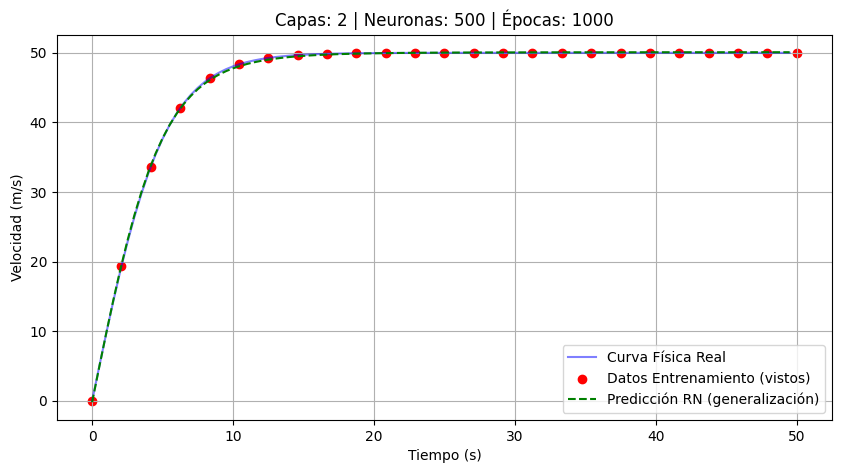

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(t_test, v_real, 'b-', label='Curva Física Real', alpha=0.5)
plt.scatter(t_train, v_train, color='red', label='Datos Entrenamiento (vistos)')
plt.plot(t_test, v_pred, 'g--', label='Predicción RN (generalización)')
plt.title(f'Capas: {NUM_CAPAS_OCULTAS} | Neuronas: {NEURONAS_POR_CAPA} | Épocas: {EPOCAS}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()


# Regresión No-Lineal

La solución analítica exacta del paracaidista (con $v_0=0$) es:

$$v(t) = v_t \tanh\!\left(\frac{g}{v_t}\,t\right)$$

Usamos `scipy.optimize.curve_fit` para ajustar los parámetros $v_t$ y $g$ directamente a los datos de entrenamiento.

In [9]:
from scipy.optimize import curve_fit

# Modelo de regresión: v(t) = vt * tanh(g/vt * t)
def modelo_regresion(t, vt, g):
    return vt * np.tanh(g / vt * t)

# Ajuste con los mismos datos de entrenamiento
t_flat = t_train.flatten()
v_flat = v_train.flatten()

# Valores iniciales cercanos a los físicos reales (vt≈50, g≈9.8)
params_opt, params_cov = curve_fit(modelo_regresion, t_flat, v_flat, p0=[50.0, 9.8])
vt_fit, g_fit = params_opt

print(f"Parámetros ajustados:")
print(f"  v_t (velocidad terminal) = {vt_fit:.4f} m/s  (real: 50.0)")
print(f"  g   (gravedad efectiva)  = {g_fit:.4f} m/s²  (real: 9.8)")

# Predicción de la regresión sobre los datos de test
v_reg = modelo_regresion(t_test.flatten(), vt_fit, g_fit)


Parámetros ajustados:
  v_t (velocidad terminal) = 50.0000 m/s  (real: 50.0)
  g   (gravedad efectiva)  = 9.8000 m/s²  (real: 9.8)


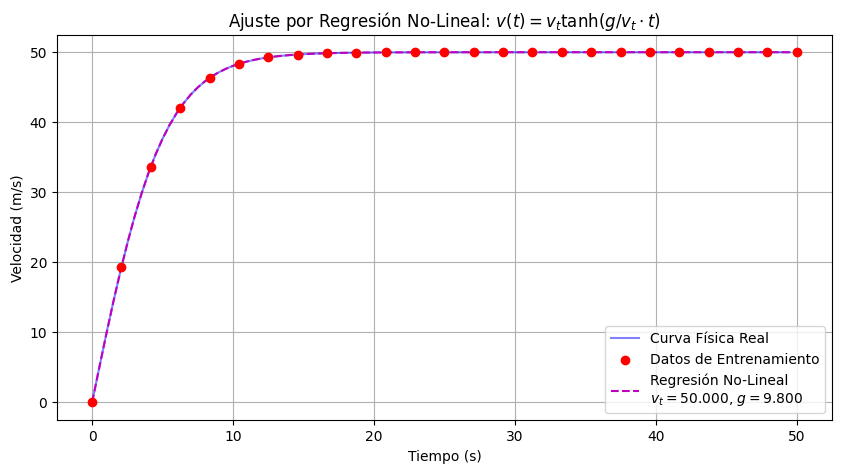

In [10]:
# Gráfica de la regresión
plt.figure(figsize=(10, 5))
plt.plot(t_test, v_real.flatten(), 'b-', label='Curva Física Real', alpha=0.5)
plt.scatter(t_train, v_train, color='red', label='Datos de Entrenamiento', zorder=5)
plt.plot(t_test, v_reg, 'm--', label=f'Regresión No-Lineal\n$v_t={vt_fit:.3f}$, $g={g_fit:.3f}$')
plt.title('Ajuste por Regresión No-Lineal: $v(t) = v_t \\tanh(g/v_t \\cdot t)$')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()


# Comparación: Red Neuronal vs Regresión No-Lineal

Se compara la red neuronal (2 capas, 500 neuronas, `tanh`, 1000 épocas) con la regresión no-lineal mediante:
- **Gráfica superpuesta** frente a la curva física real
- **MSE** (Error Cuadrático Medio) sobre los datos de test
- **MAE** (Error Absoluto Medio) sobre los datos de test

In [11]:
v_rn_comp  = model.predict(t_test).flatten()
v_real_flat = v_real.flatten()

# Métricas
mse_rn  = np.mean((v_rn_comp  - v_real_flat)**2)
mse_reg = np.mean((v_reg       - v_real_flat)**2)
mae_rn  = np.mean(np.abs(v_rn_comp  - v_real_flat))
mae_reg = np.mean(np.abs(v_reg       - v_real_flat))

print(f"\n{'Método':<35} {'MSE':>12} {'MAE':>12}")
print("-" * 61)
print(f"{'Red Neuronal (2c × 500n, tanh)':<35} {mse_rn:>12.4f} {mae_rn:>12.4f}")
print(f"{'Regresión No-Lineal':<35} {mse_reg:>12.6f} {mae_reg:>12.6f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

Método                                       MSE          MAE
-------------------------------------------------------------
Red Neuronal (2c × 500n, tanh)            0.0167       0.1050
Regresión No-Lineal                     0.000000     0.000000


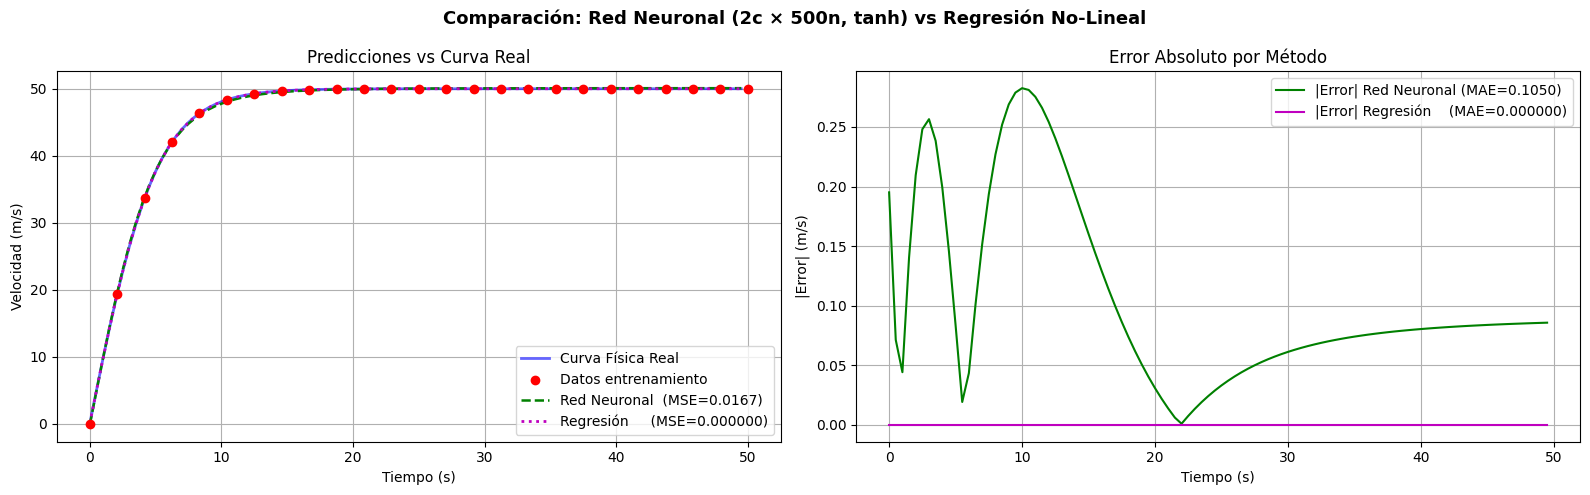

In [12]:
# Gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Panel izquierdo: curvas superpuestas ---
ax = axes[0]
ax.plot(t_test, v_real_flat,  'b-',  label='Curva Física Real',        linewidth=2, alpha=0.6)
ax.scatter(t_train, v_train,  color='red', label='Datos entrenamiento',  zorder=5)
ax.plot(t_test, v_rn_comp,   'g--', label=f'Red Neuronal  (MSE={mse_rn:.4f})',  linewidth=1.8)
ax.plot(t_test, v_reg,       'm:',  label=f'Regresión     (MSE={mse_reg:.6f})',  linewidth=2)
ax.set_title('Predicciones vs Curva Real')
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Velocidad (m/s)')
ax.legend()
ax.grid(True)

# --- Panel derecho: error absoluto ---
ax2 = axes[1]
ax2.plot(t_test, np.abs(v_rn_comp - v_real_flat), 'g-', label=f'|Error| Red Neuronal (MAE={mae_rn:.4f})')
ax2.plot(t_test, np.abs(v_reg      - v_real_flat), 'm-', label=f'|Error| Regresión    (MAE={mae_reg:.6f})')
ax2.set_title('Error Absoluto por Método')
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('|Error| (m/s)')
ax2.legend()
ax2.grid(True)

plt.suptitle('Comparación: Red Neuronal (2c × 500n, tanh) vs Regresión No-Lineal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
